# HW3 Playground

Fill in TODOs as you work through the assignment.
Implement the required sections in `model.py`, and use this notebook to orchestrate and run your solution.

In [407]:
%load_ext autoreload
%autoreload 2

from hw3_loader import HW3DataLoader
from model import svm_classifier, svm_regressor
from model import evaluate_classifier, evaluate_regressor
from utils import (
    plot_classification_results,
    plot_regression_results,
    plot_residuals,
    explore_classification_data,
    apply_pca,
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    auc
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data Loading

In [408]:
loader = HW3DataLoader()
X_clf, y_clf = loader.get_heart_disease_data('/Users/karinabellavia/Documents/CSCI1851/stencil/homework3/data/heart.csv')
df_aging = loader.get_aging_data(pickle_path="/Users/karinabellavia/Documents/CSCI1851/stencil/homework3/data/GSE139307.pkl")


# TODO: Inspect dataset shapes and missing values
# Heart Disease dataset
print("Shape of heart disease dataset:", np.shape(X_clf))
print("Number of 0/1 labels:", y_clf.value_counts().to_dict())
print("Missing values in HD dataset:", X_clf.isna().sum())
print("Duplicates in HD dataset:", X_clf.duplicated().sum())



Successfully loaded heart disease data with 1025 rows
Shape of heart disease dataset: (1025, 13)
Number of 0/1 labels: {1: 526, 0: 499}
Missing values in HD dataset: age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64
Duplicates in HD dataset: 723


/Users/karinabellavia/Documents/CSCI1851/stencil/homework3/src/hw3_loader.py:84: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data_dict = pickle.load(f)


Text(0.5, 1.0, 'Distribution of age in biological aging dataset')

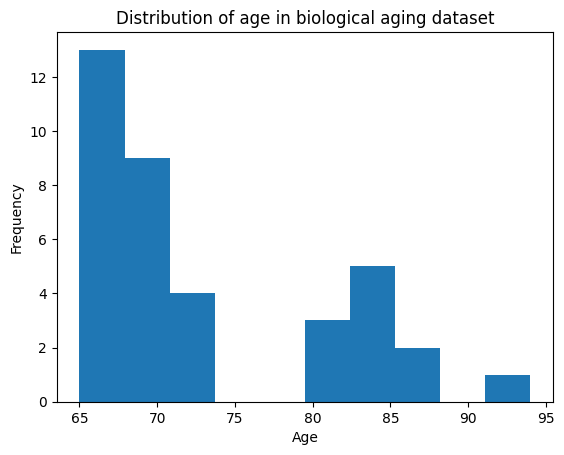

In [409]:
# TODO: Print basic summary statistics for each dataset
plt.hist(y_reg)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of age in biological aging dataset')

## Classification Task (Heart Disease)

Exploring classification dataset...


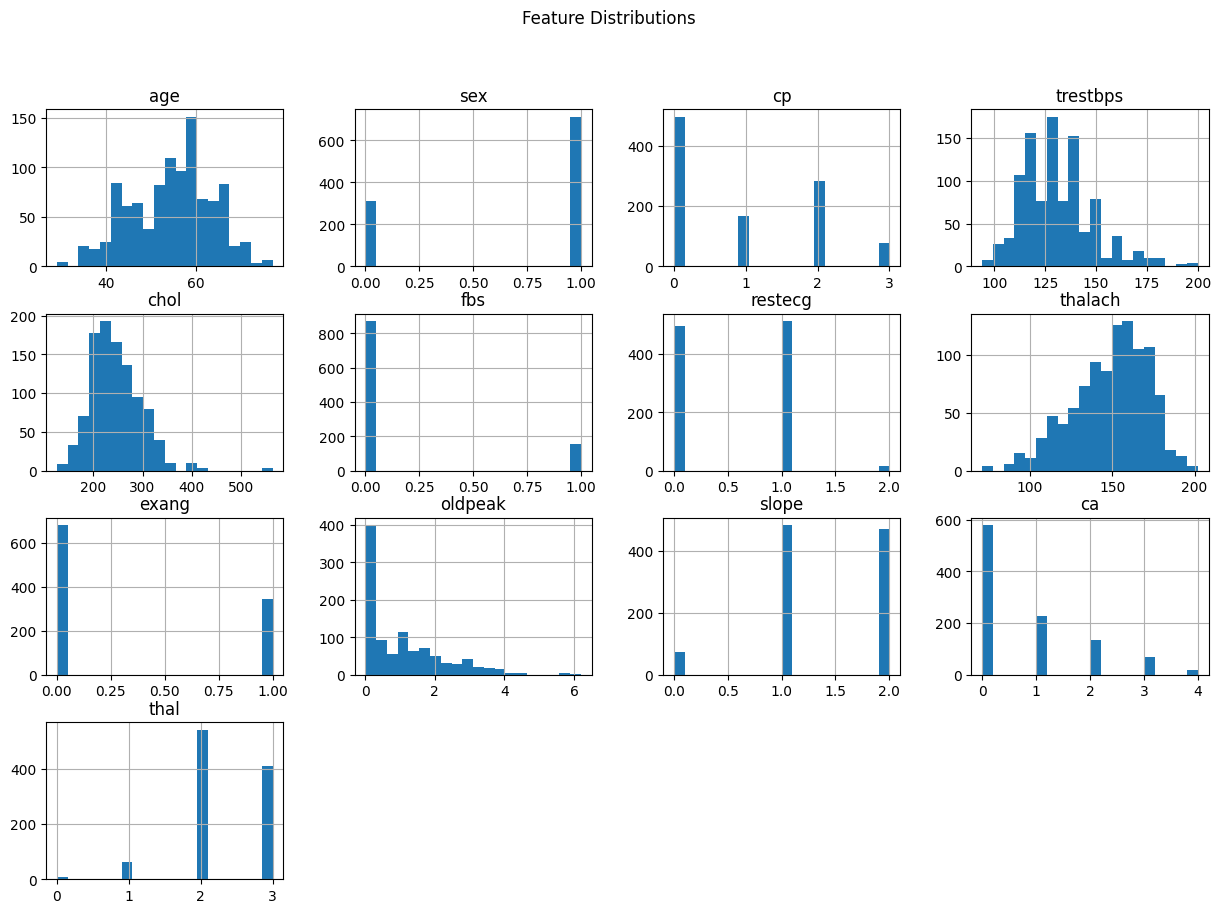

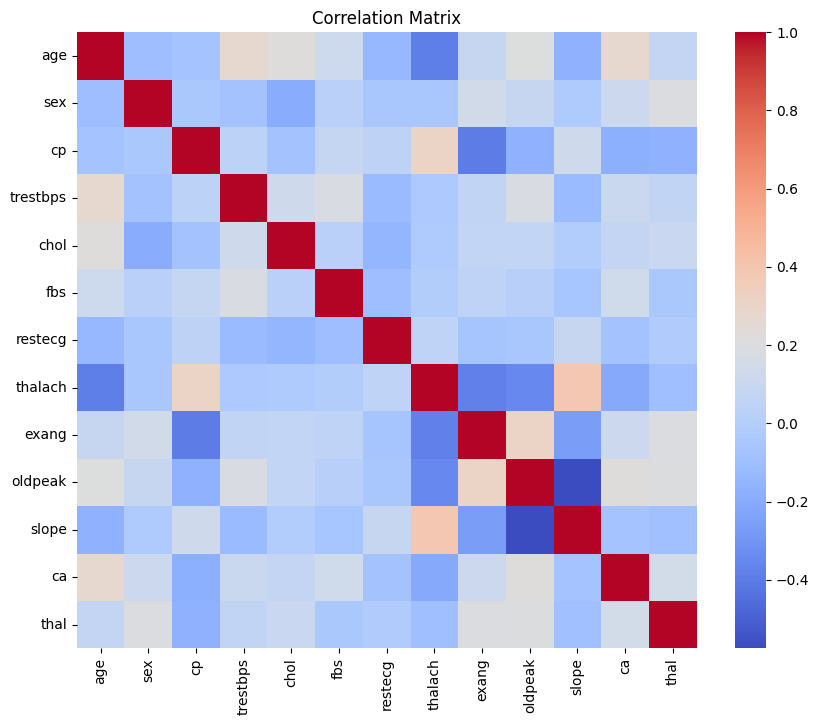

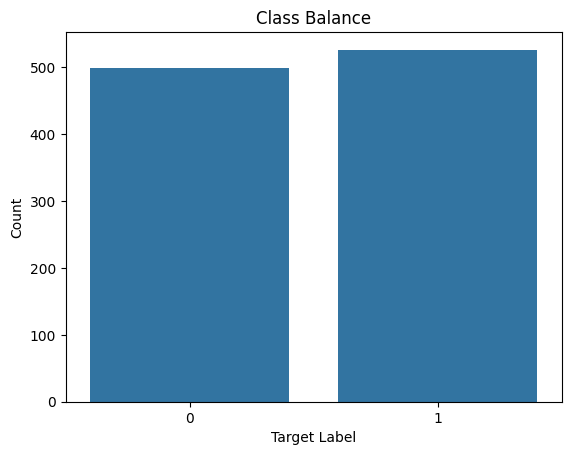

In [410]:
# TODO: Use explore_classification_data to show histograms, correlations, and class balance
# Use utils

explore_classification_data(X_clf, y_clf)


In [411]:
# TODO: Split X_clf and y_clf into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)


### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVM)

In [412]:
# TODO: Build a leakage-free pipeline for classification

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = "mean")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components = 0.95)),
    ("model", svm_classifier(kernel= "linear",C=1, degree=3, gamma="scale")),
])


### Kernel Experiments

In [413]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)

grid_search_params = {
    "linear": {"model__C": [0.1, 1, 10, 100]},
    "rbf": {"model__C": [0.1, 1, 10, 100], "model__gamma": ["scale", "auto", 0.01, 0.001]},
    "poly": {"model__C": [0.1, 1, 10, 100], "model__degree": [2,3,4], "model__gamma": ["scale", "auto", 0.01, 0.001]}
}

# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model

kernels = ['linear', 'rbf', 'poly']
results = []
cv_results = {}
best_models = {}

for kernel in kernels:
    pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = "mean")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components = 0.95)),
    ("model", svm_classifier(kernel= kernel)),
    ])

    grid_search = GridSearchCV(
        pipeline,
        param_grid=grid_search_params[kernel],
        cv = 5,
        scoring = "f1",
        n_jobs = -1
    )

    grid_search.fit(X_train, y_train)

    cv_results[kernel] = pd.DataFrame(grid_search.cv_results_)

    test_score = grid_search.score(X_test, y_test)

    results.append({
        "kernel":      kernel,
        "best_params": grid_search.best_params_,
        "cv_score":    grid_search.best_score_,
        "test_score":  test_score,
    })

    best_models[kernel] = grid_search.best_estimator_

results_df = pd.DataFrame(results).sort_values("test_score", ascending=False)

print(results_df[["kernel", "cv_score", "test_score", "best_params"]])

best_kernel = results_df.iloc[0]["kernel"]

best_model_final = best_models[best_kernel]

print(f"\nBest kernel: {best_kernel}")

   kernel  cv_score  test_score  \
1     rbf  0.971862    0.985222   
2    poly  0.974055    0.970000   
0  linear  0.866101    0.831858   

                                         best_params  
1         {'model__C': 100, 'model__gamma': 'scale'}  
2  {'model__C': 100, 'model__degree': 4, 'model__...  
0                                  {'model__C': 0.1}  

Best kernel: rbf


### Classification Metrics and Visuals

In [414]:
# TODO: Compute accuracy and F1

evaluate_results = []

for kernel, model in best_models.items():
    metrics = evaluate_classifier(model, X_test, y_test)
    metrics["kernel"] = kernel
    evaluate_results.append(metrics)

eval_df = pd.DataFrame(evaluate_results).set_index("kernel")
print(eval_df)


        accuracy  precision    recall        f1
kernel                                         
linear  0.814634   0.764228  0.912621  0.831858
rbf     0.985366   1.000000  0.970874  0.985222
poly    0.970732   1.000000  0.941748  0.970000


In [348]:

# TODO: Compute ROC-AUC or PR-AUC

roc_auc_scores = {}

for kernel, model in best_models.items():
    y_proba = model.predict_proba(X_test)
    roc_auc_scores[kernel] = roc_auc_score(y_test, y_proba[:, 1])

print('ROC-AUC SCORES')
print(roc_auc_scores)

pr_auc_scores = {}

for kernel, model in best_models.items():
    y_proba = model.predict_proba(X_test)
    pr_auc_scores[kernel] = average_precision_score(y_test, y_proba[:,1])

print('PR-AUC SCORES')
print(pr_auc_scores)

ROC-AUC SCORES
{'linear': 0.8748334285170379, 'rbf': 0.9774414620217019, 'poly': 0.9523129640205596}
PR-AUC SCORES
{'linear': 0.871211943332198, 'rbf': 0.9873573028912834, 'poly': 0.9737471021715276}


In [358]:
# TODO: Plot classification results

for kernel, model in best_models.items():
    plot_classification_results(X_clf, y_clf, model, kernel, f"{kernel}_svm_boundary")


/Users/karinabellavia/Documents/CSCI1851/stencil/homework3/.hw3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/Users/karinabellavia/Documents/CSCI1851/stencil/homework3/.hw3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/Users/karinabellavia/Documents/CSCI1851/stencil/homework3/.hw3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


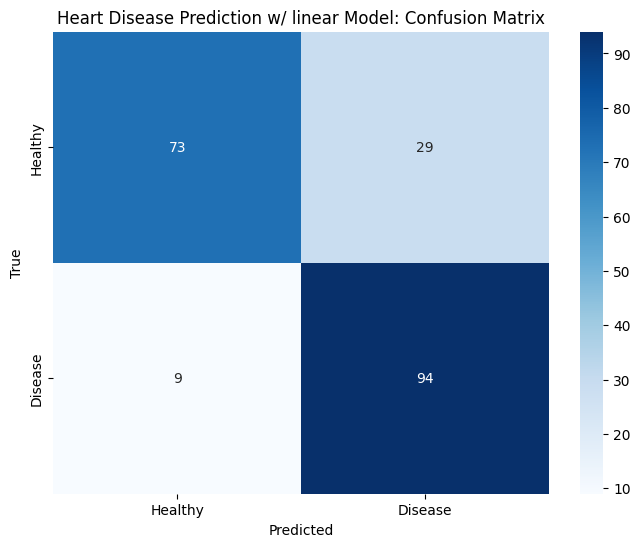

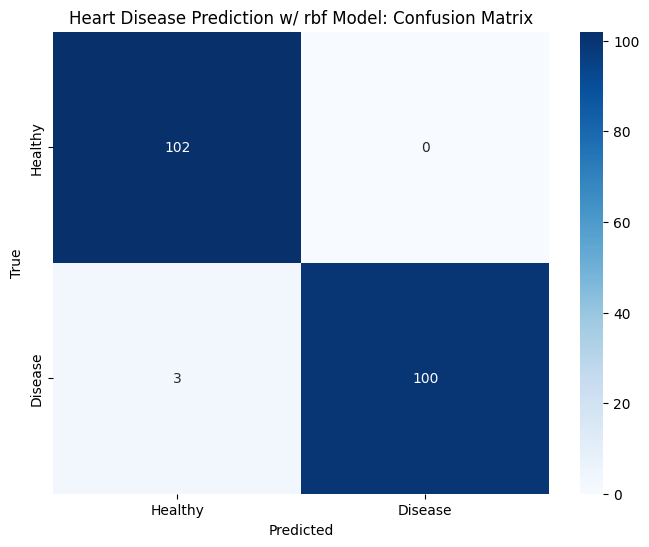

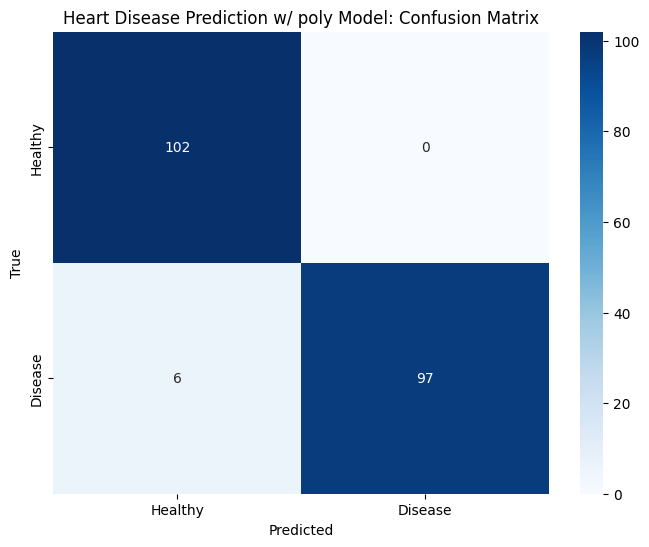

In [415]:
# Plot confusion matrices
for kernel, model in best_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Heart Disease Prediction w/ {kernel} Model: Confusion Matrix')
    plt.show()



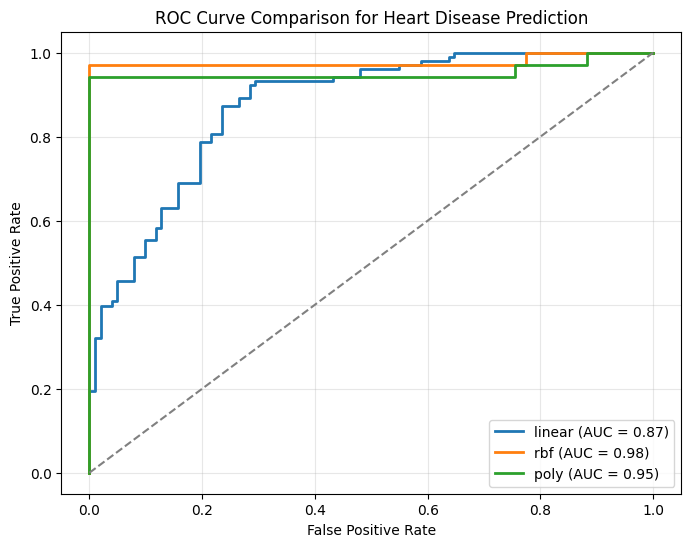

In [416]:

# TODO: compute ROC curve with roc_curve and plot it
plt.figure(figsize=(8, 6))

for kernel, model in best_models.items():
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{kernel} (AUC = {auc_score:.2f})", lw=2)

plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison for Heart Disease Prediction")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Hyperparameter Sensitivity

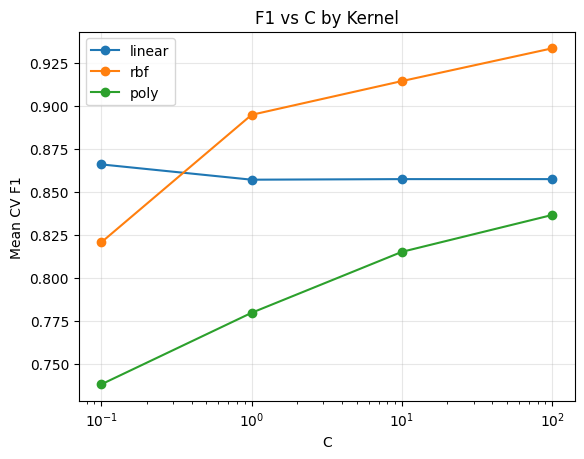

In [417]:
# TODO: Make 1-2 concise visuals of performance vs C/gamma/degree

# Example: line plot of F1 vs C for a fixed kernel

for kernel in kernels:
    df = cv_results[kernel]
    # average over other params (degree, gamma) to isolate effect of C
    grouped = df.groupby("param_model__C")["mean_test_score"].mean()
    plt.plot(grouped.index, grouped.values, marker="o", label=kernel)

plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Mean CV F1")
plt.title("F1 vs C by Kernel")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

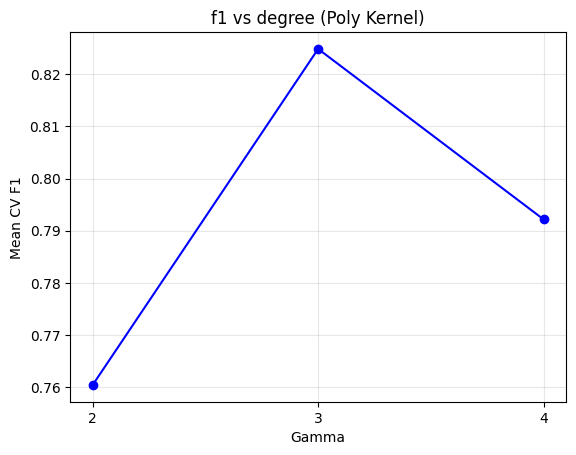

In [418]:
# line plot of f1 vs. degree for poly
df = cv_results["poly"]
grouped = df.groupby("param_model__degree")["mean_test_score"].mean()
plt.plot(grouped.index.astype(str), grouped.values, marker="o", color="blue")

plt.xlabel("Gamma")
plt.ylabel("Mean CV F1")
plt.title("f1 vs degree (Poly Kernel)")
plt.grid(alpha=0.3)
plt.show()

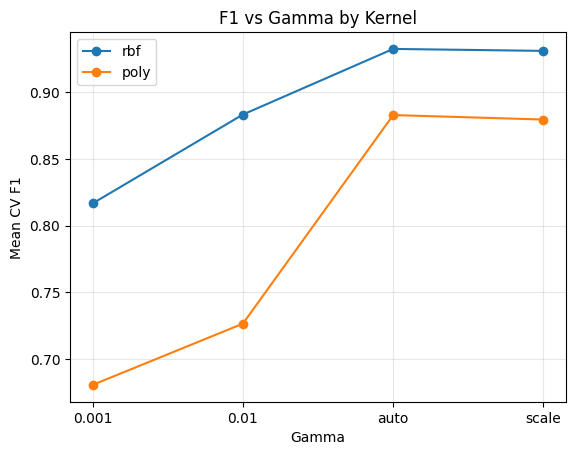

In [354]:
# line plot of f1 vs. gamma for rbf/poly

for kernel in ['rbf', 'poly']:
    df = cv_results[kernel]
    # average over other params (degree, gamma) to isolate effect of C
    grouped = df.groupby("param_model__gamma")["mean_test_score"].mean()
    plt.plot(grouped.index.astype(str), grouped.values, marker="o", label=kernel)

plt.xlabel("Gamma")
plt.ylabel("Mean CV F1")
plt.title("F1 vs Gamma by Kernel")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Regression Task (Biological Aging)

In [419]:
# TODO: Separate target column "target" from features
df_aging = loader.get_aging_data(pickle_path="/Users/karinabellavia/Documents/CSCI1851/stencil/homework3/data/GSE139307.pkl")
X_reg = df_aging.drop(columns=["age"])
y_reg = df_aging["age"]


# Biological Aging dataset
print("Shape of biological aging dataset:", np.shape(X_reg))
print("Duplicates in aging dataset:", X_reg.duplicated().sum())

is_missing = {}

X_reg_cols = X_reg.columns

for X in X_reg_cols:
    if X_reg[X].isna().sum() > 0:
        is_missing[X] = X_reg[X].isna().sum()
    else:
        continue

print("Number of missing values in biological aging dataset:", is_missing)
print("Number of features with missing values in biological aging dataset:", len(is_missing))


/Users/karinabellavia/Documents/CSCI1851/stencil/homework3/src/hw3_loader.py:84: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data_dict = pickle.load(f)


Shape of biological aging dataset: (37, 485515)
Duplicates in aging dataset: 0
Number of missing values in biological aging dataset: {'cg00121626': np.int64(3), 'cg00198603': np.int64(3), 'cg00259584': np.int64(1), 'cg00394712': np.int64(1), 'cg00461991': np.int64(1), 'cg00614360': np.int64(2), 'cg00893493': np.int64(1), 'cg00931375': np.int64(3), 'cg01037637': np.int64(1), 'cg01147467': np.int64(1), 'cg01278720': np.int64(1), 'cg01413698': np.int64(1), 'cg01424889': np.int64(6), 'cg01550828': np.int64(37), 'cg01582532': np.int64(1), 'cg01675596': np.int64(1), 'cg01780171': np.int64(1), 'cg01813738': np.int64(3), 'cg02000275': np.int64(1), 'cg02018902': np.int64(1), 'cg02052410': np.int64(2), 'cg02155405': np.int64(1), 'cg02321096': np.int64(1), 'cg02389942': np.int64(1), 'cg02470587': np.int64(1), 'cg02553872': np.int64(1), 'cg02587129': np.int64(1), 'cg02789126': np.int64(2), 'cg02856727': np.int64(1), 'cg02925799': np.int64(1), 'cg02943194': np.int64(1), 'cg02987635': np.int64(5), '

Text(0.5, 1.0, 'Distribution of age in biological aging dataset')

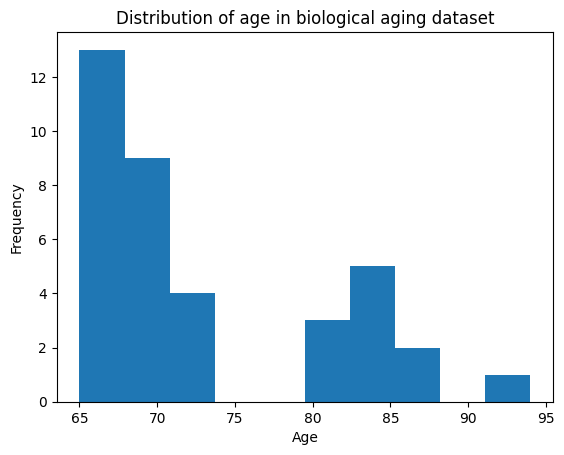

In [420]:
# TODO: Print basic summary statistics for each dataset
plt.hist(y_reg)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of age in biological aging dataset')

In [421]:

X_reg = df_aging.drop(columns=["age"])
y_reg = df_aging["age"]

# TODO: Handle missing values with column-wise mean imputation (do not drop rows/cols)
X_reg_imputer = X_reg.drop(columns=["dataset","tissue_type","gender"])

# I found one whole column is NAN so I dropped that (cg01550828)

#all_nan_cols = X_reg_imputer.columns[X_reg_imputer.isna().all()].tolist()
#print("All-NaN columns:", all_nan_cols)

X_reg_imputer = X_reg_imputer.dropna(axis=1, how="all")

imputer = SimpleImputer(strategy="mean")

X_reg_imputer = pd.DataFrame(imputer.fit_transform(X_reg_imputer), columns=X_reg_imputer.columns)

X_reg_imputer["tissue_type"] = X_reg["tissue_type"].values

X_reg_imputer["gender"] = X_reg["gender"].values

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X_reg_imputer["gender"] = le.fit_transform(X_reg_imputer["gender"])

X_reg_imputer["tissue_type"] = le.fit_transform(X_reg_imputer["tissue_type"])



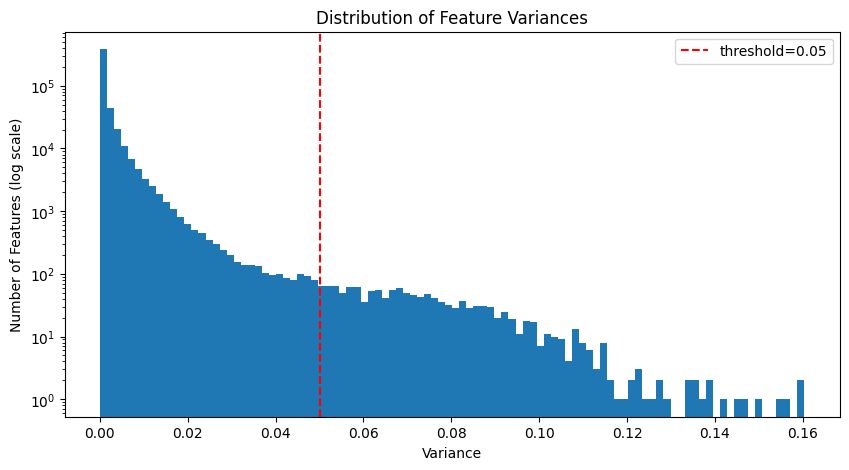

threshold=0.01: 15406 features remaining
threshold=0.02: 4991 features remaining
threshold=0.03: 2717 features remaining
threshold=0.05: 1345 features remaining


In [422]:
variances = X_reg_imputer.var()

plt.figure(figsize=(10, 5))
plt.hist(variances, bins=100, log=True) 
plt.xlabel("Variance")
plt.ylabel("Number of Features (log scale)")
plt.title("Distribution of Feature Variances")
plt.axvline(x=0.05, color="red", linestyle="--", label="threshold=0.05")
plt.legend()
plt.show()

for threshold in [0.01, 0.02, 0.03, 0.05]:
    count = (variances > threshold).sum()
    print(f"threshold={threshold}: {count} features remaining")

In [423]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.05)
X_filtered_values = selector.fit_transform(X_reg_imputer)
surviving_columns = X_reg_imputer.columns[selector.get_support()]

X_filtered = pd.DataFrame(X_filtered_values, columns=surviving_columns)

In [424]:
# TODO: Split X_reg and y_reg into training and testing sets

X_train_age, X_test_age, y_train_age, y_test_age = train_test_split(X_filtered, y_reg, test_size=0.2, random_state=42)


### Build Pipeline (Imputation -> Scaling -> Optional PCA -> SVR)

In [267]:
# TODO: Build a leakage-free pipeline for regression
pipeline_regressor = Pipeline([
    ("imputer", SimpleImputer(strategy = "mean")),
    #("scaler", StandardScaler()),
    ("pca", PCA(n_components = 10)),
    ("model", svm_regressor(kernel= "linear",C=1, degree=3, gamma="scale")),
])


### Kernel Experiments

In [404]:
# TODO: Loop over kernels ["linear", "poly", "rbf"]
# TODO: Tune hyperparameters (C, degree, gamma)

grid_search_params_regressor = {
    "linear": {"model__C": [0.001, 0.01, 0.1, 1, 10, 100]},
    "rbf":    {"model__C": [0.001, 0.01, 0.1, 1, 10, 100], "model__gamma": ["scale", "auto", 0.01, 0.001]},
    "poly":   {"model__C": [0.001, 0.01, 0.1, 1, 10, 100], "model__degree": [2, 3, 4], "model__gamma": ["scale", "auto", 0.01, 0.001]},
}
# TODO: Fit models and track metrics
# TODO: Compare kernels and select best model

kernels = ['linear', 'rbf', 'poly']
results_regressor = []
cv_results_regressor = {}
best_models_regressor = {}

for kernel in kernels:
    pipeline_regressor = Pipeline([
    ("imputer", SimpleImputer(strategy = "mean")),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components = 10 )),
    ("model", svm_regressor(kernel= kernel)),
    ])

    grid_search = GridSearchCV(
        pipeline_regressor,
        param_grid=grid_search_params_regressor[kernel],
        cv = 5,
        scoring = "r2",
        n_jobs = -1
    )

    grid_search.fit(X_train_age, y_train_age)

    cv_results_regressor[kernel] = pd.DataFrame(grid_search.cv_results_)

    test_score = grid_search.score(X_test_age, y_test_age)

    results_regressor.append({
        "kernel":      kernel,
        "best_params": grid_search.best_params_,
        "cv_score":    grid_search.best_score_,
        "test_score":  test_score,
    })

    best_models_regressor[kernel] = grid_search.best_estimator_

results_df_regressor = pd.DataFrame(results_regressor).sort_values("test_score", ascending=False)

print(results_df_regressor[["kernel", "cv_score", "test_score", "best_params"]])

best_kernel_regressor = results_df_regressor.iloc[0]["kernel"]

best_model_final = best_models_regressor[best_kernel_regressor]

print(f"\nBest kernel: {best_kernel_regressor}")


   kernel  cv_score  test_score  \
0  linear -0.319078    0.016787   
1     rbf -0.283441   -0.002306   
2    poly -0.246840   -0.006525   

                                         best_params  
0                                {'model__C': 0.001}  
1              {'model__C': 1, 'model__gamma': 0.01}  
2  {'model__C': 1, 'model__degree': 2, 'model__ga...  

Best kernel: linear


### Regression Metrics and Visuals

In [405]:
# TODO: Compute MAE, RMSE, and R^2

evaluate_results_regressor = []

for kernel, model in best_models_regressor.items():
    metrics = evaluate_regressor(model = model, X_test=X_test_age, y_test=y_test_age)
    metrics["kernel"] = kernel
    evaluate_results_regressor.append(metrics)

eval_df_regressor = pd.DataFrame(evaluate_results_regressor).set_index("kernel")
print(eval_df_regressor)


             mse       mae        r2
kernel                              
linear  5.651466  4.197628  0.016787
rbf     5.706074  4.191600 -0.002306
poly    5.718071  4.116305 -0.006525


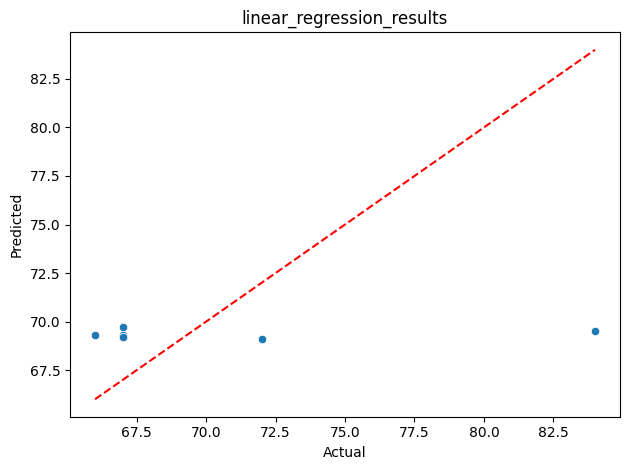

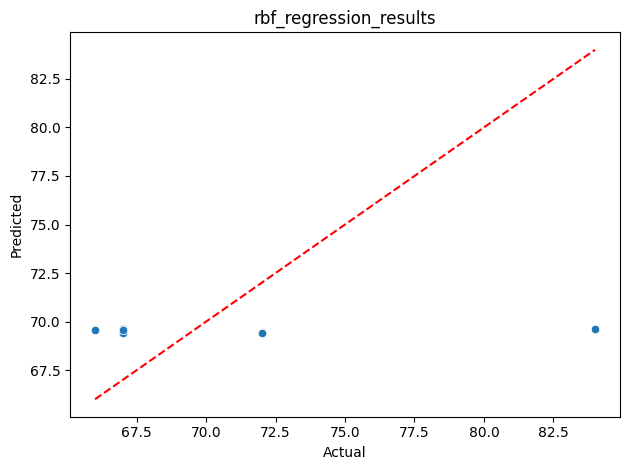

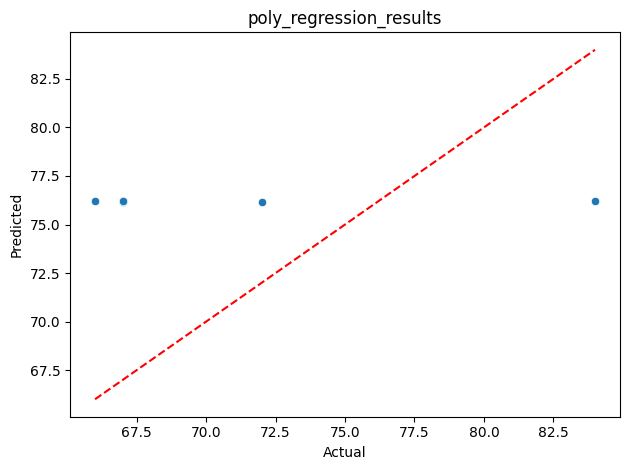

In [402]:
# TODO: Plot parity (predicted vs actual) and residuals

for kernel, model in best_models_regressor.items():
    y_pred = model.predict(X_test_age)
    plot_regression_results(y_test_age, y_pred, model, f"{kernel}_regression_results")
    plt.show() 

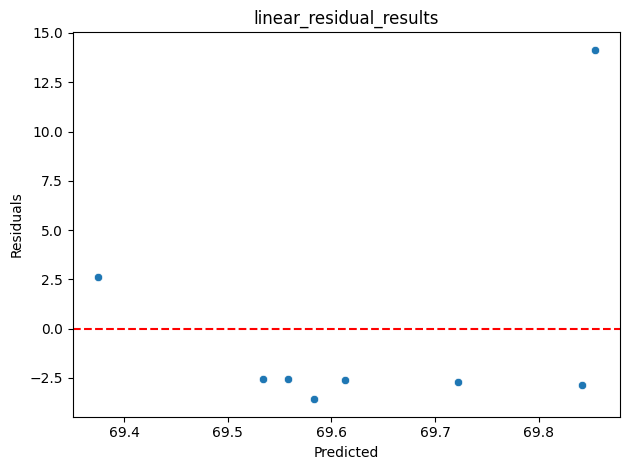

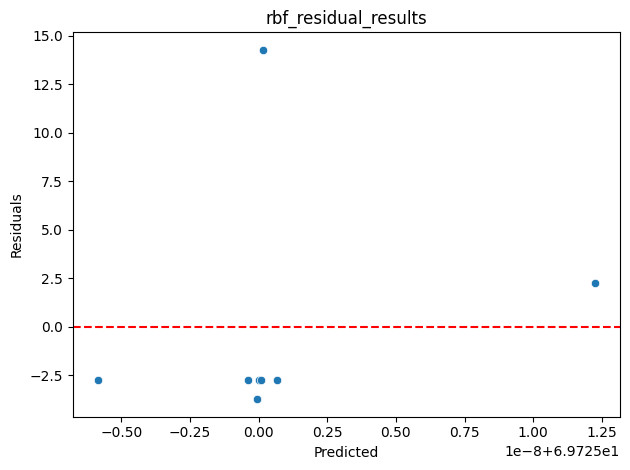

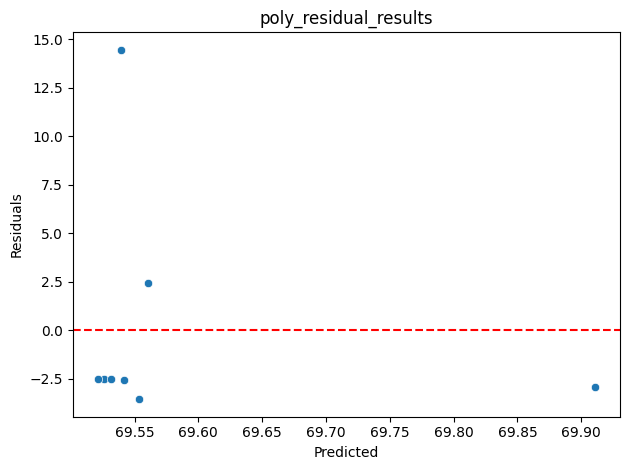

In [397]:
for kernel, model in best_models_regressor.items():
    y_pred = model.predict(X_test_age)
    plot_residuals(y_test_age, y_pred, model, f"{kernel}_residual_results")
    plt.show() 

### Hyperparameter Sensitivity (Regression)

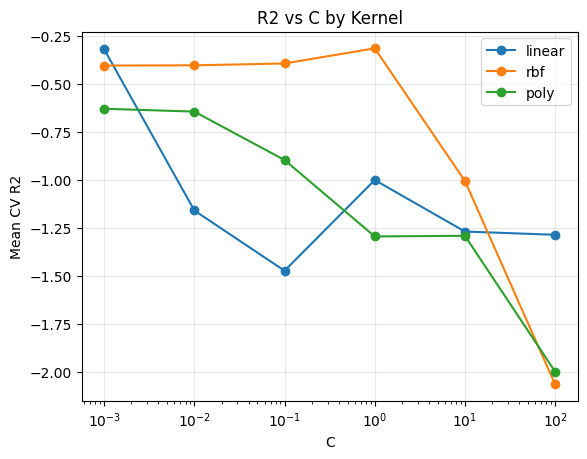

In [384]:
# TODO: Visualize performance vs C/gamma/degree
# Example: line plot of RMSE vs C for a fixed kernel

# TODO: Make 1-2 concise visuals of performance vs C/gamma/degree

for kernel in kernels:
    df = cv_results_regressor[kernel]
    # average over other params (degree, gamma) to isolate effect of C
    grouped = df.groupby("param_model__C")["mean_test_score"].mean()
    plt.plot(grouped.index, grouped.values, marker="o", label=kernel)

plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Mean CV R2")
plt.title("R2 vs C by Kernel")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

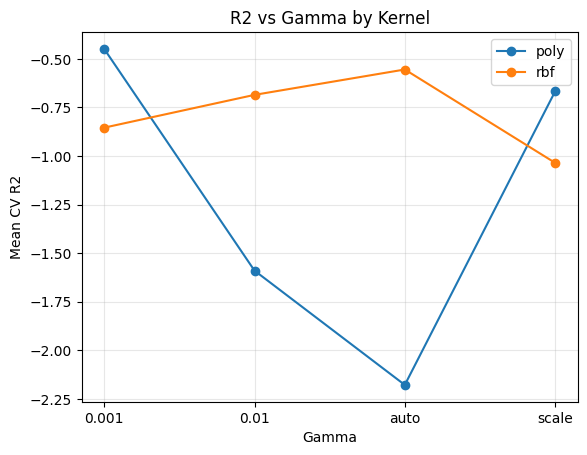

In [406]:
# line plot of f1 vs. gamma for rbf/poly

for kernel in ['poly', 'rbf']:
    df = cv_results_regressor[kernel]
    # average over other params (degree, gamma) to isolate effect of C
    grouped = df.groupby("param_model__gamma")["mean_test_score"].mean()
    plt.plot(grouped.index.astype(str), grouped.values, marker="o", label=kernel)

plt.xlabel("Gamma")
plt.ylabel("Mean CV R2")
plt.title("R2 vs Gamma by Kernel")
plt.legend()
plt.grid(alpha=0.3)
plt.show()